# Installer les bibliothèques nécessaires

In [ ]:
!pip install sqlalchemy 
!pip install psycopg2 
!pip install pandas  
!pip install matplotlib
!pip install seaborn

# Importer les bibliothèques nécessaires

In [6]:
import os
from sqlalchemy import create_engine
import psycopg2
from psycopg2 import sql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importer le fichier sur la qualité de l'air en ile de france

In [ ]:
chemin_Qualite_Air = "QualiteAir.csv" # Définir le chmin vers le fichier csv
df = pd.read_csv(chemin_Qualite_Air, sep=";") # Lire le fichier
df.sample(10) # Afficher 10 lignes aléatoires du DataFrame

,Date,Code Insee,NO2,O3,PM10,geom,Annee Jointure,Geo Point 2D,commune,departement
154965,2017-01-03,77276,27,8,39,"{""coordinates"": [[[2.8794366531, 48.9430660265...",2016,"48.9234117667, 2.8694785524",MAREUIL-LES-MEAUX,SEINE-ET-MARNE
1184177,2014-02-25,91109,11,34,12,"{""coordinates"": [[[2.1209154917, 48.4676415479...",2016,"48.4639638069, 2.14322450938",BRIERES-LES-SCELLES,ESSONNE
1539401,2016-10-17,95572,31,26,20,"{""coordinates"": [[[2.1160598436, 49.0231626396...",2016,"49.0444862396, 2.12906447581",SAINT-OUEN-L'AUMONE,VAL-D'OISE
703382,2015-10-26,95487,21,13,40,"{""coordinates"": [[[2.2636155929, 49.1359343529...",2016,"49.1497259419, 2.26959916421",PERSAN,VAL-D'OISE
1555997,2015-09-24,77420,24,24,24,"{""coordinates"": [[[2.721334545, 49.034419475],...",2016,"49.0384037054, 2.69708899618",SAINT-MARD,SEINE-ET-MARNE
883387,2018-03-28,78251,27,36,12,"{""coordinates"": [[[2.0468155719, 48.8747115947...",2016,"48.8852662025, 2.05425920916",FOURQUEUX,YVELINES
276238,2014-02-01,77020,23,31,14,"{""coordinates"": [[[3.2123149266, 48.6917685755...",2016,"48.6754725776, 3.19169509554",BANNOST-VILLEGAGNON,SEINE-ET-MARNE
979187,2016-01-06,91017,13,24,15,"{""coordinates"": [[[2.0546540212, 48.5765305449...",2016,"48.590628416, 2.0592711773",ANGERVILLIERS,ESSONNE
300438,2014-08-11,91001,11,34,17,"{""coordinates"": [[[2.1708378554, 48.3150363178...",2016,"48.3433938326, 2.19123458772",ABBEVILLE-LA-RIVIERE,ESSONNE
1693527,2016-08-20,95078,7,33,19,"{""coordinates"": [[[2.0455906273, 49.0829825208...",2016,"49.0832310447, 2.03212828108",BOISSY-L'AILLERIE,VAL-D'OISE


# Analyse exploratoire du DataFrame

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2047963 entries, 0 to 2047962
Data columns (total 10 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   Date            object
 1   Code Insee      int64 
 2   NO2             int64 
 3   O3              int64 
 4   PM10            int64 
 5   geom            object
 6   Annee Jointure  int64 
 7   Geo Point 2D    object
 8   commune         object
 9   departement     object
dtypes: int64(5), object(5)
memory usage: 156.2+ MB


In [14]:
df.isnull().sum()

Date              0
Code Insee        0
NO2               0
O3                0
PM10              0
geom              0
Annee Jointure    0
Geo Point 2D      0
commune           0
departement       0
dtype: int64

In [15]:
df.describe()

,Code Insee,NO2,O3,PM10,Annee Jointure
count,2.047963e+06,2.047963e+06,2.047963e+06,2.047963e+06,2047963.0
mean,8.366051e+04,1.822314e+01,3.182442e+01,2.766059e+01,2016.0
std,7.740458e+03,9.625376e+00,1.088031e+01,1.476040e+01,0.0
min,7.510100e+04,1.000000e+00,1.000000e+00,2.000000e+00,2016.0
25%,7.731600e+04,1.100000e+01,2.500000e+01,1.700000e+01,2016.0
50%,7.831400e+04,1.500000e+01,3.100000e+01,2.400000e+01,2016.0
75%,9.164800e+04,2.300000e+01,3.800000e+01,3.400000e+01,2016.0
max,9.569000e+04,8.500000e+01,1.050000e+02,1.220000e+02,2016.0


In [17]:
doublon = df.duplicated()
doublon

0          False
1          False
2          False
3          False
4          False
           ...  
2047958    False
2047959    False
2047960    False
2047961    False
2047962    False
Length: 2047963, dtype: bool

In [18]:
df.head()

,Date,Code Insee,NO2,O3,PM10,geom,Annee Jointure,Geo Point 2D,commune,departement
0,2016-02-19,94067,44,24,34,"{""coordinates"": [[[2.4275751568, 48.8415707058...",2016,"48.8410208466, 2.41853928644",SAINT-MANDE,VAL-DE-MARNE
1,2015-01-02,91098,11,23,35,"{""coordinates"": [[[2.0341842327, 48.4645205852...",2016,"48.4557682089, 2.05140502516",BOUTERVILLIERS,ESSONNE
2,2015-02-04,77402,12,29,34,"{""coordinates"": [[[3.3549394043, 48.8382830041...",2016,"48.8202537071, 3.36436418348",SAINT-BARTHELEMY,SEINE-ET-MARNE
3,2015-11-07,95019,23,18,17,"{""coordinates"": [[[2.4165339707, 48.9984997879...",2016,"48.9859786056, 2.41754697068",ARNOUVILLE,VAL-D'OISE
4,2015-06-02,95323,12,36,24,"{""coordinates"": [[[2.0076268511, 49.0082365264...",2016,"49.0110945823, 2.03330227191",JOUY-LE-MOUTIER,VAL-D'OISE


In [19]:
# Séparer la colonne 'Geo Point 2D' contenant les coordonnées géographiques en 2 colonnes distinctes : latitude et longitude
df[['latitude', 'longitude']] = df['Geo Point 2D'].str.split(',', expand=True) 
df

,Date,Code Insee,NO2,O3,PM10,geom,Annee Jointure,Geo Point 2D,commune,departement,latitude,longitude
0,2016-02-19,94067,44,24,34,"{""coordinates"": [[[2.4275751568, 48.8415707058...",2016,"48.8410208466, 2.41853928644",SAINT-MANDE,VAL-DE-MARNE,48.8410208466,2.41853928644
1,2015-01-02,91098,11,23,35,"{""coordinates"": [[[2.0341842327, 48.4645205852...",2016,"48.4557682089, 2.05140502516",BOUTERVILLIERS,ESSONNE,48.4557682089,2.05140502516
2,2015-02-04,77402,12,29,34,"{""coordinates"": [[[3.3549394043, 48.8382830041...",2016,"48.8202537071, 3.36436418348",SAINT-BARTHELEMY,SEINE-ET-MARNE,48.8202537071,3.36436418348
3,2015-11-07,95019,23,18,17,"{""coordinates"": [[[2.4165339707, 48.9984997879...",2016,"48.9859786056, 2.41754697068",ARNOUVILLE,VAL-D'OISE,48.9859786056,2.41754697068
4,2015-06-02,95323,12,36,24,"{""coordinates"": [[[2.0076268511, 49.0082365264...",2016,"49.0110945823, 2.03330227191",JOUY-LE-MOUTIER,VAL-D'OISE,49.0110945823,2.03330227191
...,...,...,...,...,...,...,...,...,...,...,...,...
2047958,2017-10-17,91035,13,28,47,"{""coordinates"": [[[1.9717045904, 48.4370857736...",2016,"48.4537634435, 1.95617937408",AUTHON-LA-PLAINE,ESSONNE,48.4537634435,1.95617937408
2047959,2017-03-27,93061,51,41,59,"{""coordinates"": [[[2.4106903466, 48.8784751065...",2016,"48.8852204631, 2.40598240359",LE PRE-SAINT-GERVAIS,SEINE-SAINT-DENIS,48.8852204631,2.40598240359
2047960,2015-07-23,91215,16,45,22,"{""coordinates"": [[[2.5042417079, 48.6718070339...",2016,"48.6885324126, 2.51718985682",EPINAY-SOUS-SENART,ESSONNE,48.6885324126,2.51718985682
2047961,2015-07-28,77376,13,33,20,"{""coordinates"": [[[2.7830993199, 48.9381014214...",2016,"48.9322660645, 2.76793657723",PRECY-SUR-MARNE,SEINE-ET-MARNE,48.9322660645,2.76793657723


In [20]:
# Supprimer les colonnes inutiles du DataFrame : 'geom', 'Annee Jointure' et 'Geo Point 2D'
df.drop(['geom','Annee Jointure', 'Geo Point 2D'], axis=1, inplace=True) # l'argument inplace permet d'appliquer l'opération directement dans le DataFrame d'origine sans crée de copie
df

,Date,Code Insee,NO2,O3,PM10,commune,departement,latitude,longitude
0,2016-02-19,94067,44,24,34,SAINT-MANDE,VAL-DE-MARNE,48.8410208466,2.41853928644
1,2015-01-02,91098,11,23,35,BOUTERVILLIERS,ESSONNE,48.4557682089,2.05140502516
2,2015-02-04,77402,12,29,34,SAINT-BARTHELEMY,SEINE-ET-MARNE,48.8202537071,3.36436418348
3,2015-11-07,95019,23,18,17,ARNOUVILLE,VAL-D'OISE,48.9859786056,2.41754697068
4,2015-06-02,95323,12,36,24,JOUY-LE-MOUTIER,VAL-D'OISE,49.0110945823,2.03330227191
...,...,...,...,...,...,...,...,...,...
2047958,2017-10-17,91035,13,28,47,AUTHON-LA-PLAINE,ESSONNE,48.4537634435,1.95617937408
2047959,2017-03-27,93061,51,41,59,LE PRE-SAINT-GERVAIS,SEINE-SAINT-DENIS,48.8852204631,2.40598240359
2047960,2015-07-23,91215,16,45,22,EPINAY-SOUS-SENART,ESSONNE,48.6885324126,2.51718985682
2047961,2015-07-28,77376,13,33,20,PRECY-SUR-MARNE,SEINE-ET-MARNE,48.9322660645,2.76793657723


In [21]:
# Renommer les colonnes du DataFrame pour des noms plus clairs
df = df.rename(columns = {
    'Date' : 'date',
    'Code Insee' : 'code_insee',
    'NO2' : 'dioxyde_azote_no2',
    'O3' : 'ozone_o3',
    'PM10' : 'particule_fines_pm10',
    'commune' : 'nom_commune',
    'departement' : 'nom_departement'
})
df

,date,code_insee,dioxyde_azote_no2,ozone_o3,particule_fines_pm10,nom_commune,nom_departement,latitude,longitude
0,2016-02-19,94067,44,24,34,SAINT-MANDE,VAL-DE-MARNE,48.8410208466,2.41853928644
1,2015-01-02,91098,11,23,35,BOUTERVILLIERS,ESSONNE,48.4557682089,2.05140502516
2,2015-02-04,77402,12,29,34,SAINT-BARTHELEMY,SEINE-ET-MARNE,48.8202537071,3.36436418348
3,2015-11-07,95019,23,18,17,ARNOUVILLE,VAL-D'OISE,48.9859786056,2.41754697068
4,2015-06-02,95323,12,36,24,JOUY-LE-MOUTIER,VAL-D'OISE,49.0110945823,2.03330227191
...,...,...,...,...,...,...,...,...,...
2047958,2017-10-17,91035,13,28,47,AUTHON-LA-PLAINE,ESSONNE,48.4537634435,1.95617937408
2047959,2017-03-27,93061,51,41,59,LE PRE-SAINT-GERVAIS,SEINE-SAINT-DENIS,48.8852204631,2.40598240359
2047960,2015-07-23,91215,16,45,22,EPINAY-SOUS-SENART,ESSONNE,48.6885324126,2.51718985682
2047961,2015-07-28,77376,13,33,20,PRECY-SUR-MARNE,SEINE-ET-MARNE,48.9322660645,2.76793657723


# Quelques visualisations

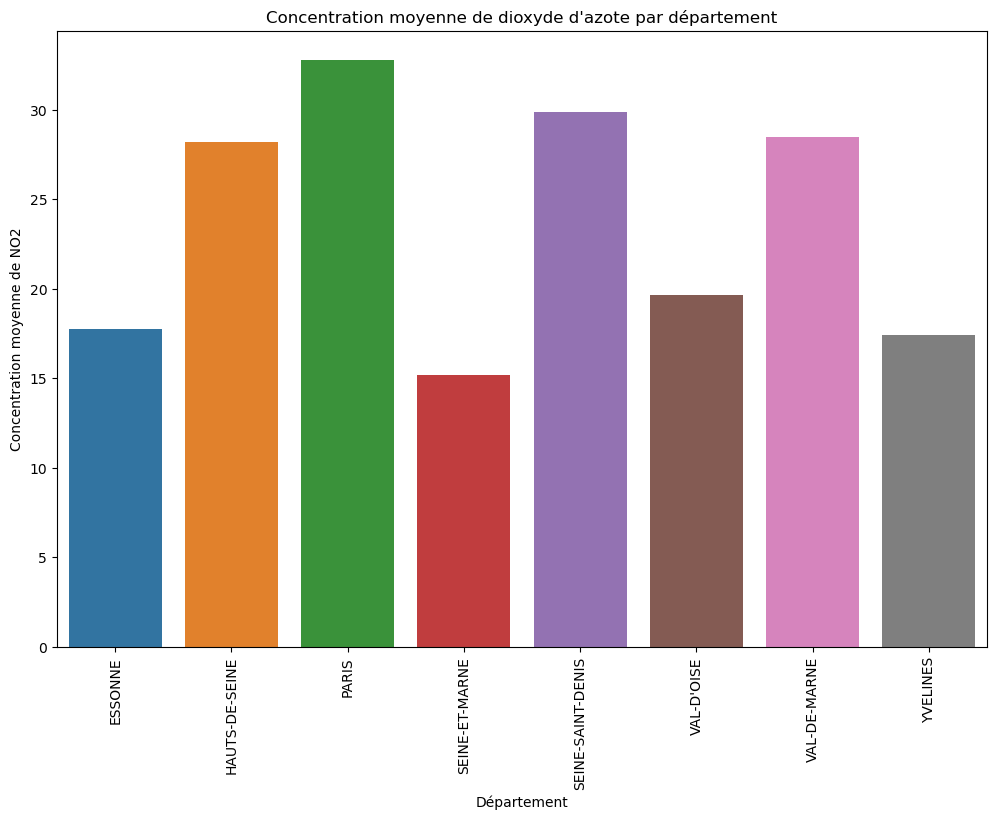

,nom_departement,dioxyde_azote_no2
0,ESSONNE,17.740949
1,HAUTS-DE-SEINE,28.215027
2,PARIS,32.757188
3,SEINE-ET-MARNE,15.176967
4,SEINE-SAINT-DENIS,29.846628
5,VAL-D'OISE,19.677155
6,VAL-DE-MARNE,28.457090
7,YVELINES,17.405523


In [22]:
# Calculer la moyenne de dioxyde_azote_no2 par département

df_moyenne_no2_departement = df.groupby('nom_departement')['dioxyde_azote_no2'].mean().reset_index()

# Visualiser les résultats
plt.figure(figsize=(12, 8))
sns.barplot(x='nom_departement', y='dioxyde_azote_no2', data=df_moyenne_no2_departement)
plt.xticks(rotation=90)
plt.title("Concentration moyenne de dioxyde d'azote par département")
plt.xlabel("Département")
plt.ylabel("Concentration moyenne de NO2")
plt.show()

# Afficher les résultats sous forme de tableau
df_moyenne_no2_departement

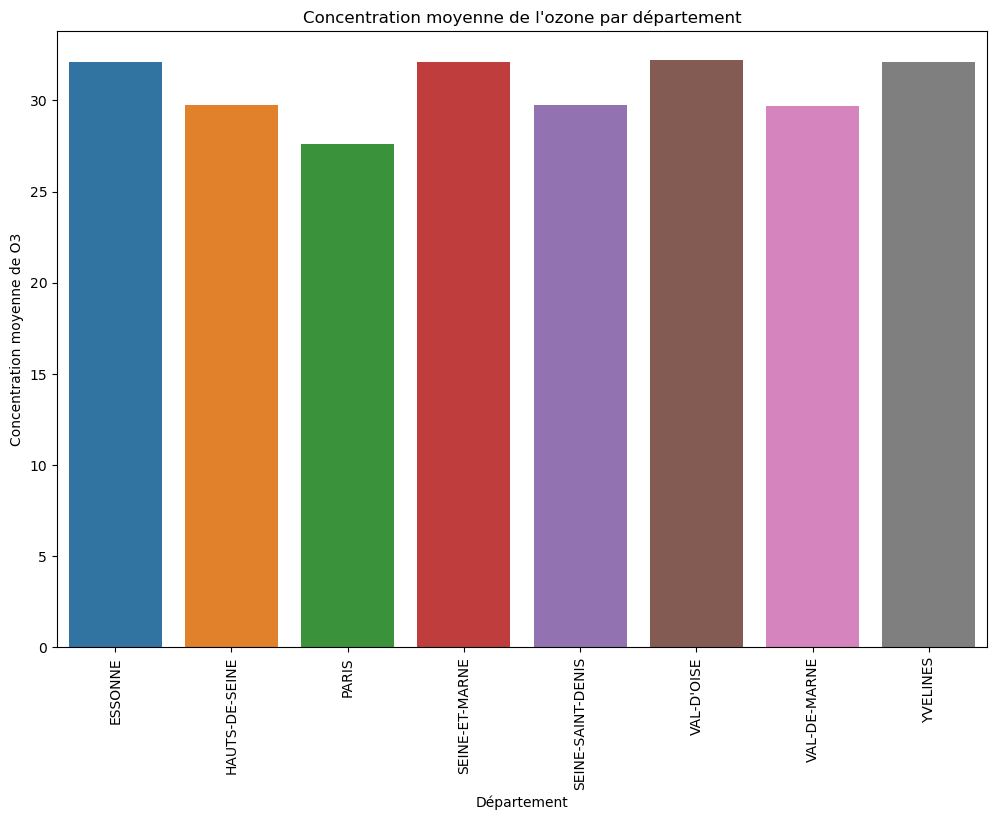

,nom_departement,ozone_o3
0,ESSONNE,32.102471
1,HAUTS-DE-SEINE,29.734519
2,PARIS,27.594142
3,SEINE-ET-MARNE,32.099150
4,SEINE-SAINT-DENIS,29.744839
5,VAL-D'OISE,32.204923
6,VAL-DE-MARNE,29.718890
7,YVELINES,32.117177


In [24]:
#  Calculer la moyenne de ozone_o3 par département

df_moyenne_ozone_o3_departement = df.groupby('nom_departement')['ozone_o3'].mean().reset_index()

# Visualiser les résultats
plt.figure(figsize=(12, 8))
sns.barplot(x='nom_departement', y='ozone_o3', data=df_moyenne_ozone_o3_departement)
plt.xticks(rotation=90)
plt.title("Concentration moyenne de l'ozone par département")
plt.xlabel("Département")
plt.ylabel("Concentration moyenne de O3")
plt.show()

# Afficher les résultats sous forme de tableau
df_moyenne_ozone_o3_departement

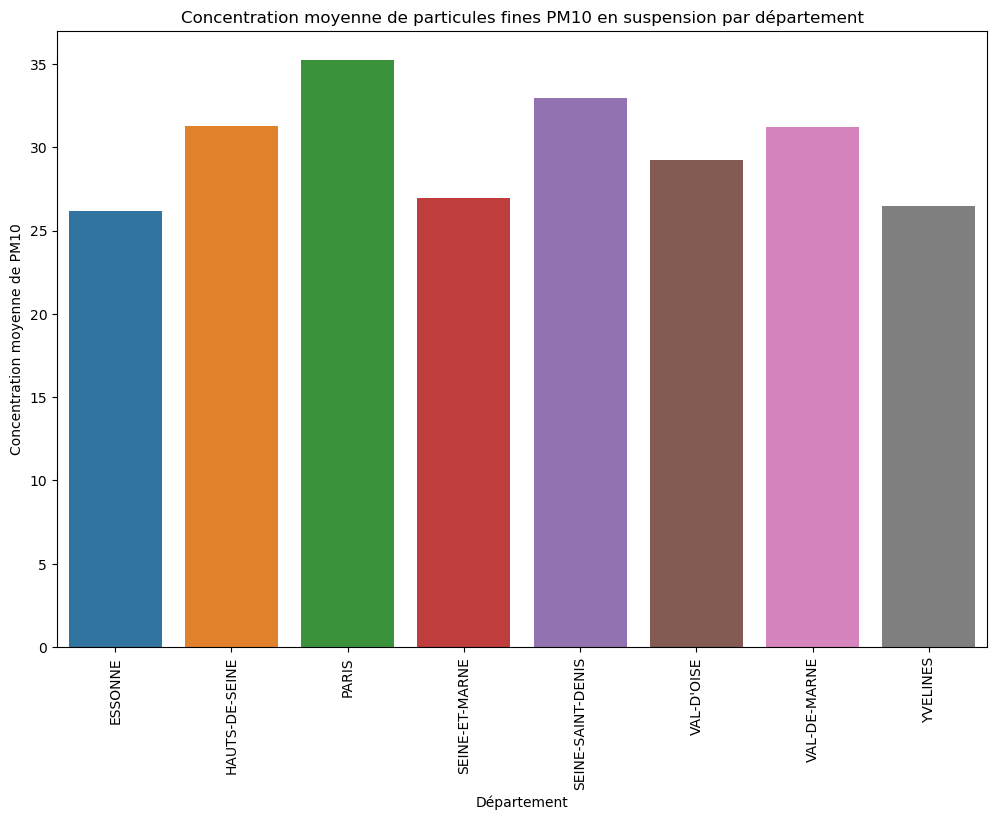

,nom_departement,particule_fines_pm10
0,ESSONNE,26.157097
1,HAUTS-DE-SEINE,31.300946
2,PARIS,35.219063
3,SEINE-ET-MARNE,26.964564
4,SEINE-SAINT-DENIS,32.983186
5,VAL-D'OISE,29.259501
6,VAL-DE-MARNE,31.226874
7,YVELINES,26.484317


In [26]:
# Calculer la moyenne de particules en suspension par département

df_moyenne_particule_fines_pm10_departement = df.groupby('nom_departement')['particule_fines_pm10'].mean().reset_index()

# Visualiser les résultats
plt.figure(figsize=(12, 8))
sns.barplot(x='nom_departement', y='particule_fines_pm10', data=df_moyenne_particule_fines_pm10_departement)
plt.xticks(rotation=90)
plt.title("Concentration moyenne de particules fines PM10 en suspension par département")
plt.xlabel("Département")
plt.ylabel("Concentration moyenne de PM10")
plt.show()

# Afficher les résultats sous forme de tableau
df_moyenne_particule_fines_pm10_departement

# Injesction du DataFrame dans une base de données PostgreSQL

In [ ]:
# Créer un fichier .env afin d'y stocker les informations de connexion de la base de données postgreSQL

# Chemin complet vers ton fichier .env
chemin_env_air = ".env"
charger_env(chemin_env_air=chemin_env_air)

# Maintenant, récupèrer les variables
user = os.getenv("PG_USER")
password = os.getenv("PG_PASSWORD")
host = os.getenv("PG_HOST")
port = os.getenv("PG_PORT")
db = os.getenv("PG_DB")

In [ ]:
# Définir l'URL de connexion
DATABASE_URL = f'postgresql://{user}:{password}@{host}:{port}/{db}'

# Créer l'engine SQLAlchemy
engine = create_engine(DATABASE_URL)

# Injecter le DataFrame dans la base de données PostgreSQL
df.to_sql('pollution', engine, if_exists='replace', index=False)
print("DataFrame chargé dans la table 'pollution_data' avec succès !")

# Importer le fichier sur la population

In [ ]:
chemin_population = "population.csv" 
df = pd.read_csv(chemin_population, sep=";", encoding="latin1") 
df.sample(10)  # Afficher 10 lignes aléatoires du DataFrame

,codgeo,libgeo,an,p_pop
14879,39415,Petit-Noir,2021,1070.0
34708,95304,Hédouville,2021,279.0
31599,80674,Rivery,2021,3620.0
4190,12202,Rodez,2021,24207.0
9578,27327,Hectomare,2021,217.0
6307,19016,Bar,2021,304.0
22557,60132,Catigny,2021,183.0
1846,05163,Le Sauze-du-Lac,2021,153.0
23226,61153,Écouché-les-Vallées,2021,2197.0
17501,48182,Saint-Sauveur-de-Ginestoux,2021,59.0


# Analyse exploratoire du DataFrame

In [28]:
df.dtypes

codgeo     object
libgeo     object
an          int64
p_pop     float64
dtype: object

In [29]:
df.isnull().sum()

codgeo     0
libgeo     0
an         0
p_pop     17
dtype: int64

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34935 entries, 0 to 34934
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   codgeo  34935 non-null  object 
 1   libgeo  34935 non-null  object 
 2   an      34935 non-null  int64  
 3   p_pop   34918 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ MB


In [31]:
df.describe()

,an,p_pop
count,34935.0,3.491800e+04
mean,2021.0,1.930467e+03
std,0.0,1.498724e+04
min,2021.0,0.000000e+00
25%,2021.0,1.970000e+02
50%,2021.0,4.570000e+02
75%,2021.0,1.162000e+03
max,2021.0,2.133111e+06


In [32]:
# Suppression des lignes contenant des valeurs nulles dans la colonne 'p_pop'.
# On aurait aussi pu choisir une autre méthode d'imputation pour traiter ces valeurs manquantes.
df = df.dropna(subset=["p_pop"])
df


,codgeo,libgeo,an,p_pop
0,01001,L'Abergement-Clémenciat,2021,832.0
1,01002,L'Abergement-de-Varey,2021,267.0
2,01004,Ambérieu-en-Bugey,2021,14854.0
3,01005,Ambérieux-en-Dombes,2021,1897.0
4,01006,Ambléon,2021,113.0
...,...,...,...,...
34913,97420,Sainte-Suzanne,2021,24293.0
34914,97421,Salazie,2021,7243.0
34915,97422,Le Tampon,2021,81943.0
34916,97423,Les Trois-Bassins,2021,6899.0


In [33]:
# Renommer les colonnes du DataFrame pour des noms plus clairs

df = df.rename(columns = {
    'codgeo' : 'code_geo',
    'libgeo' : 'nom_commune',
    'an' : 'annee_population',
    'p_pop' : 'nombre_population'
})
df

,code_geo,nom_commune,annee_population,nombre_population
0,01001,L'Abergement-Clémenciat,2021,832.0
1,01002,L'Abergement-de-Varey,2021,267.0
2,01004,Ambérieu-en-Bugey,2021,14854.0
3,01005,Ambérieux-en-Dombes,2021,1897.0
4,01006,Ambléon,2021,113.0
...,...,...,...,...
34913,97420,Sainte-Suzanne,2021,24293.0
34914,97421,Salazie,2021,7243.0
34915,97422,Le Tampon,2021,81943.0
34916,97423,Les Trois-Bassins,2021,6899.0


In [34]:
# Supprimer les colonnes inutiles du DataFrame : 'annee_population'
df.drop(['annee_population'], axis=1, inplace=True) # l'argument inplace permet d'appliquer l'opération directement dans la dataFrame d'origine sans crée de copie
df

,code_geo,nom_commune,nombre_population
0,01001,L'Abergement-Clémenciat,832.0
1,01002,L'Abergement-de-Varey,267.0
2,01004,Ambérieu-en-Bugey,14854.0
3,01005,Ambérieux-en-Dombes,1897.0
4,01006,Ambléon,113.0
...,...,...,...
34913,97420,Sainte-Suzanne,24293.0
34914,97421,Salazie,7243.0
34915,97422,Le Tampon,81943.0
34916,97423,Les Trois-Bassins,6899.0


In [ ]:
# Chemin complet vers ton fichier .env
chemin_env_air = ".env"
charger_env(chemin_env_air=chemin_env_air)

# Maintenant, récupèrer les variables
user = os.getenv("PG_USER")
password = os.getenv("PG_PASSWORD")
host = os.getenv("PG_HOST")
port = os.getenv("PG_PORT")
db = os.getenv("PG_DB")

In [ ]:
# Définir l'URL de connexion
DATABASE_URL = f'postgresql://{user}:{password}@{host}:{port}/{db}'

# Créer l'engine SQLAlchemy
engine = create_engine(DATABASE_URL)

# Injecter le DataFrame dans la base de données PostgreSQL
df.to_sql('pollution', engine, if_exists='replace', index=False)
print("DataFrame chargé dans la table 'pollution_data' avec succès !")